# 🦟 LeishCheck - Treinamento do Modelo de IA

Este notebook treina um modelo de classificação de imagens para detectar Leishmaniose Cutânea.

**Dataset:** 10.000+ imagens de leishmaniose + 10.000+ imagens de não-leishmaniose

**Arquitetura:** MobileNetV2 (Transfer Learning) otimizado para TensorFlow.js

**GPU:** T4 gratuita do Google Colab

## 📦 Passo 1: Instalação de Dependências

In [3]:
!pip install -q tensorflowjs gdown Pillow matplotlib scikit-learn

## 🔗 Passo 2: Conectar ao Google Drive e Baixar Imagens

In [9]:
from google.colab import drive
import os
import shutil
from pathlib import Path

# Montar Google Drive
drive.mount('/content/drive')

# IDs das pastas compartilhadas do Google Drive
LEISH_FOLDER_ID = '19Uy62U3a8Bw7AePjlZ0dlhgkfPWSTxas'  # Pasta leishmaniose
NAO_LEISH_FOLDER_ID = '17nMMVEJh9Pm21-JZCs-R4hgxyPm2mW0C'  # Pasta não_leishmaniose

# Caminhos no Drive (ajuste se necessário)
DRIVE_LEISH_PATH = '/content/drive/MyDrive/Imagens de leishmaniose /leishimaniose'  # @param {type:"string"}
DRIVE_NAO_LEISH_PATH = '/content/drive/MyDrive/Imagens de não leishmaniose /Nao_leishimaniose'  # @param {type:"string"}

# Criar estrutura local
os.makedirs('data/train/leishmaniose', exist_ok=True)
os.makedirs('data/train/nao_leishmaniose', exist_ok=True)
os.makedirs('data/validation/leishmaniose', exist_ok=True)
os.makedirs('data/validation/nao_leishmaniose', exist_ok=True)

print('✅ Estrutura de pastas criada')
print(f'📁 Caminho leishmaniose: {DRIVE_LEISH_PATH}')
print(f'📁 Caminho não-leishmaniose: {DRIVE_NAO_LEISH_PATH}')

# Verificar se as pastas existem
if os.path.exists(DRIVE_LEISH_PATH):
    leish_count = len(list(Path(DRIVE_LEISH_PATH).glob('*.png'))) + len(list(Path(DRIVE_LEISH_PATH).glob('*.jpg')))
    print(f'✅ Encontradas {leish_count} imagens de leishmaniose')
else:
    print(f'⚠️ Pasta não encontrada: {DRIVE_LEISH_PATH}')
    print('   Verifique o caminho ou ajuste manualmente acima')

if os.path.exists(DRIVE_NAO_LEISH_PATH):
    nao_leish_count = len(list(Path(DRIVE_NAO_LEISH_PATH).glob('*.png'))) + len(list(Path(DRIVE_NAO_LEISH_PATH).glob('*.jpg')))
    print(f'✅ Encontradas {nao_leish_count} imagens de não-leishmaniose')
else:
    print(f'⚠️ Pasta não encontrada: {DRIVE_NAO_LEISH_PATH}')
    print('   Verifique o caminho ou ajuste manualmente acima')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Estrutura de pastas criada
📁 Caminho leishmaniose: /content/drive/MyDrive/Imagens de leishmaniose /leishimaniose
📁 Caminho não-leishmaniose: /content/drive/MyDrive/Imagens de não leishmaniose /Nao_leishimaniose
✅ Encontradas 2193 imagens de leishmaniose
✅ Encontradas 1990 imagens de não-leishmaniose


## 🔍 Passo 2.1: Encontrar Caminhos Automaticamente (OPCIONAL)

Se os caminhos acima não funcionaram, execute esta célula para encontrar automaticamente:

In [8]:
# Buscar pastas automaticamente
import glob

print('🔍 Buscando pastas de imagens no Drive...')
print()

# Buscar pasta de leishmaniose
leish_patterns = [
    '/content/drive/MyDrive/**/leishimaniose',
    '/content/drive/MyDrive/**/leishmaniose',
    '/content/drive/MyDrive/**/Imagens*leish*/leishimaniose',
    '/content/drive/MyDrive/**/Imagens*leish*/leishmaniose'
]

for pattern in leish_patterns:
    matches = glob.glob(pattern, recursive=True)
    if matches:
        print(f'✅ Leishmaniose encontrada em:')
        for match in matches:
            img_count = len(list(Path(match).glob('*.png'))) + len(list(Path(match).glob('*.jpg')))
            print(f'   {match} ({img_count} imagens)')
        break

print()

# Buscar pasta de não-leishmaniose
nao_leish_patterns = [
    '/content/drive/MyDrive/**/Nao_leishimaniose',
    '/content/drive/MyDrive/**/nao_leishmaniose',
    '/content/drive/MyDrive/**/Imagens*não*leish*/Nao_leishimaniose',
    '/content/drive/MyDrive/**/Imagens*nao*leish*/Nao_leishimaniose'
]

for pattern in nao_leish_patterns:
    matches = glob.glob(pattern, recursive=True)
    if matches:
        print(f'✅ Não-leishmaniose encontrada em:')
        for match in matches:
            img_count = len(list(Path(match).glob('*.png'))) + len(list(Path(match).glob('*.jpg')))
            print(f'   {match} ({img_count} imagens)')
        break

print()
print('💡 Copie os caminhos acima e cole na célula anterior (Passo 2) se necessário')

🔍 Buscando pastas de imagens no Drive...

✅ Leishmaniose encontrada em:
   /content/drive/MyDrive/Inteligência artificial treinada e matérias de treinamento/Dataset/leishimaniose (0 imagens)
   /content/drive/MyDrive/Imagens de leishmaniose /leishimaniose (2193 imagens)

✅ Não-leishmaniose encontrada em:
   /content/drive/MyDrive/Inteligência artificial treinada e matérias de treinamento/Dataset/Nao_leishimaniose (0 imagens)
   /content/drive/MyDrive/Imagens de não leishmaniose /Nao_leishimaniose (1990 imagens)

💡 Copie os caminhos acima e cole na célula anterior (Passo 2) se necessário


## 🔀 Passo 3: Dividir Dataset (80% treino / 20% validação)

In [42]:
import shutil
import random
from pathlib import Path

def split_simple(source_path, train_dest, val_dest, split_ratio=0.8):
    """Divisão simples: embaralha todos os arquivos e divide 80/20"""
    extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']
    images = []
    for ext in extensions:
        images.extend(list(Path(source_path).glob(ext)))

    if len(images) == 0:
        print(f'⚠️ Nenhuma imagem encontrada em {source_path}')
        return 0, 0

    # Embaralhar com seed fixo para reprodutibilidade
    random.seed(42)
    random.shuffle(images)

    split_idx = int(len(images) * split_ratio)
    train_imgs = images[:split_idx]
    val_imgs   = images[split_idx:]

    for img in train_imgs:
        shutil.copy(img, train_dest)
    for img in val_imgs:
        shutil.copy(img, val_dest)

    print(f'   📁 Total: {len(images)} | Treino: {len(train_imgs)} | Validação: {len(val_imgs)}')
    return len(train_imgs), len(val_imgs)

# Limpar pastas antes de copiar (evita duplicatas de tentativas anteriores)
import shutil as sh
for folder in ['data/train/leishmaniose', 'data/train/nao_leishmaniose',
               'data/validation/leishmaniose', 'data/validation/nao_leishmaniose']:
    sh.rmtree(folder, ignore_errors=True)
    Path(folder).mkdir(parents=True, exist_ok=True)

print('🔄 Dividindo dataset...')
print()

print('📊 Leishmaniose:')
train_leish, val_leish = split_simple(
    DRIVE_LEISH_PATH,
    'data/train/leishmaniose',
    'data/validation/leishmaniose'
)

print('📊 Não-leishmaniose:')
train_nao, val_nao = split_simple(
    DRIVE_NAO_LEISH_PATH,
    'data/train/nao_leishmaniose',
    'data/validation/nao_leishmaniose'
)

print()
print('=' * 50)
print(f'✅ Treino:    {train_leish + train_nao:,} imagens')
print(f'✅ Validação: {val_leish + val_nao:,} imagens')
print(f'✅ Total:     {train_leish + train_nao + val_leish + val_nao:,} imagens')
print('=' * 50)


🔄 Dividindo dataset...

📊 Leishmaniose:
   📁 Total: 2193 | Treino: 1754 | Validação: 439
📊 Não-leishmaniose:
   📁 Total: 1990 | Treino: 1592 | Validação: 398

✅ Treino:    3,346 imagens
✅ Validação: 837 imagens
✅ Total:     4,183 imagens


## 🖼️ Passo 4: Visualizar Amostras do Dataset

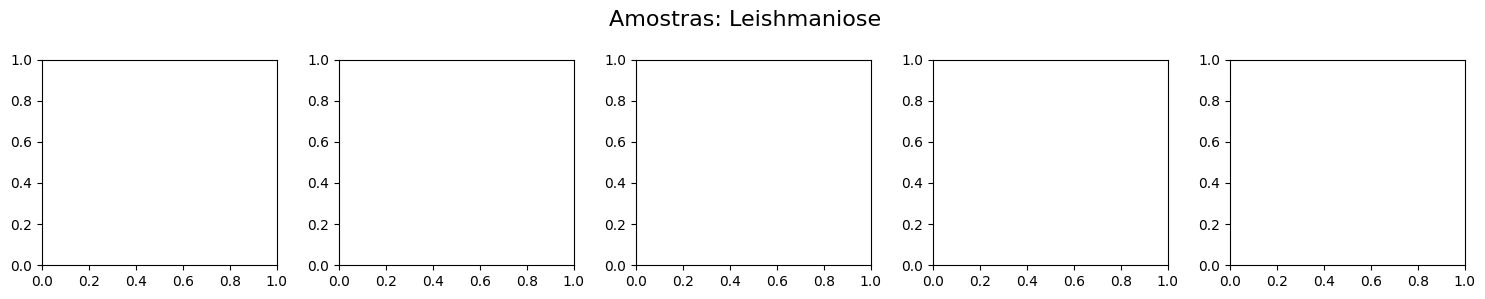

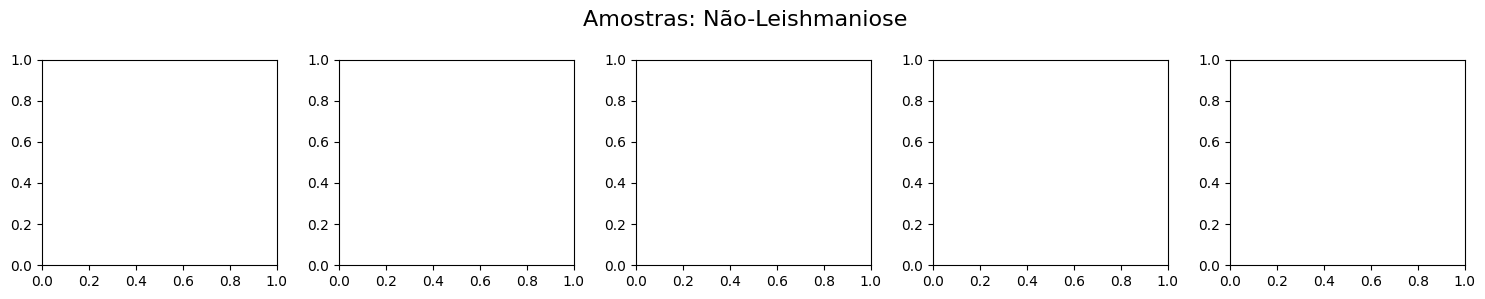

In [43]:
import matplotlib.pyplot as plt
from PIL import Image
import random

def show_samples(class_path, class_name, n=5):
    images = list(Path(class_path).glob('*.jpg'))[:n]
    fig, axes = plt.subplots(1, n, figsize=(15, 3))
    fig.suptitle(f'Amostras: {class_name}', fontsize=16)

    for ax, img_path in zip(axes, images):
        img = Image.open(img_path)
        ax.imshow(img)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_samples('data/train/leishmaniose', 'Leishmaniose')
show_samples('data/train/nao_leishmaniose', 'Não-Leishmaniose')

## 🔧 Passo 5: Configurar Data Augmentation

In [44]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 16  # Menor para dataset pequeno

# SEM augmentation — imagens já são augmentadas
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    'data/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    'data/validation',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f'✅ Generators configurados')
print(f'   Classes: {train_generator.class_indices}')


Found 3346 images belonging to 2 classes.
Found 837 images belonging to 2 classes.
✅ Generators configurados
   Classes: {'leishmaniose': 0, 'nao_leishmaniose': 1}


## 🏗️ Passo 6: Construir Modelo (Transfer Learning com MobileNetV2)

In [45]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Base pré-treinada (ImageNet)
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Congelar base inicialmente
base_model.trainable = False

# Adicionar camadas customizadas
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(2, activation='softmax')(x)  # 2 classes

model = Model(inputs=base_model.input, outputs=output)

# Compilar
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,620,098 (9.99 MB)

 Trainable params: 361,602 (1.38 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

## 🎯 Passo 7: Treinar Modelo (Fase 1 - Base Congelada)

In [46]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model_phase1.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history_phase1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,          # Menos épocas
    callbacks=callbacks,
    verbose=1
)

print('✅ Fase 1 concluída')


Epoch 1/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9188 - loss: 0.2027 - precision_5: 0.9188 - recall_5: 0.9188
Epoch 1: val_accuracy improved from None to 0.99761, saving model to best_model_phase1.keras

Epoch 1: finished saving model to best_model_phase1.keras
210/210 ━━━━━━━━━━━━━━━━━━━━ 47s 164ms/step - accuracy: 0.9695 - loss: 0.0793 - precision_5: 0.9695 - recall_5: 0.9695 - val_accuracy: 0.9976 - val_loss: 0.0066 - val_precision_5: 0.9976 - val_recall_5: 0.9976 - learning_rate: 0.0010
Epoch 2/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9917 - loss: 0.0231 - precision_5: 0.9917 - recall_5: 0.9917
Epoch 2: val_accuracy did not improve from 0.99761
210/210 ━━━━━━━━━━━━━━━━━━━━ 16s 74ms/step - accuracy: 0.9919 - loss: 0.0223 - precision_5: 0.9919 - recall_5: 0.9919 - val_accuracy: 0.9976 - val_loss: 0.0086 - val_precision_5: 0.9976 - val_recall_5: 0.9976 - learning_rate: 0.0010
Epoch 3/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9967 - 

## 🔓 Passo 8: Fine-Tuning (Fase 2 - Descongelar Camadas)

In [47]:
# Descongelar apenas últimas 20 camadas (menos que antes)
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=0.00005),  # LR bem menor
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

history_phase2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

print('✅ Fine-tuning concluído')


Epoch 1/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9879 - loss: 0.0345 - precision_6: 0.9879 - recall_6: 0.9879
Epoch 1: val_accuracy did not improve from 1.00000
210/210 ━━━━━━━━━━━━━━━━━━━━ 51s 164ms/step - accuracy: 0.9877 - loss: 0.0346 - precision_6: 0.9877 - recall_6: 0.9877 - val_accuracy: 1.0000 - val_loss: 1.2130e-04 - val_precision_6: 1.0000 - val_recall_6: 1.0000 - learning_rate: 5.0000e-05
Epoch 2/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9925 - loss: 0.0188 - precision_6: 0.9925 - recall_6: 0.9925
Epoch 2: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 2: val_accuracy did not improve from 1.00000
210/210 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.9943 - loss: 0.0141 - precision_6: 0.9943 - recall_6: 0.9943 - val_accuracy: 1.0000 - val_loss: 9.1936e-06 - val_precision_6: 1.0000 - val_recall_6: 1.0000 - learning_rate: 5.0000e-05
Epoch 3/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9952 - loss: 0

## 📊 Passo 9: Avaliar Modelo

53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 1.0000 - loss: 1.9177e-06 - precision_6: 1.0000 - recall_6: 1.0000

📈 Métricas Finais:
  Loss: 0.0000
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 179ms/step

📋 Classification Report:
                  precision    recall  f1-score   support

    Leishmaniose       1.00      1.00      1.00       439
Não-Leishmaniose       1.00      1.00      1.00       398

        accuracy                           1.00       837
       macro avg       1.00      1.00      1.00       837
    weighted avg       1.00      1.00      1.00       837



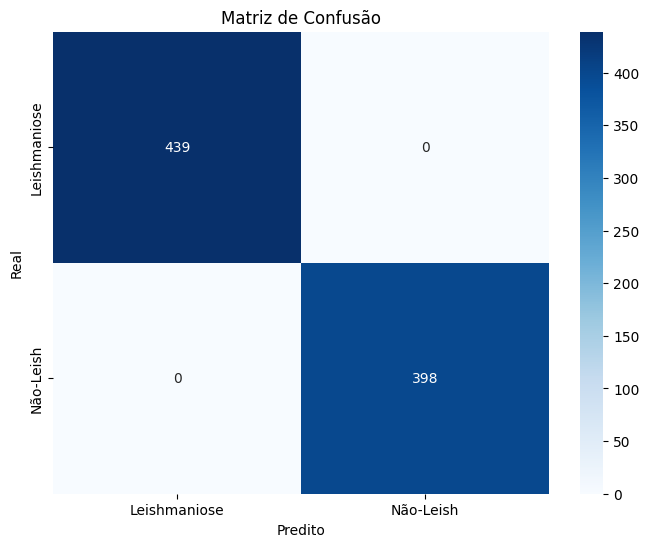

In [48]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns

# Avaliar
results = model.evaluate(val_generator, verbose=1)
print(f'\n📈 Métricas Finais:')
print(f'  Loss: {results[0]:.4f}')
print(f'  Accuracy: {results[1]:.4f}')
print(f'  Precision: {results[2]:.4f}')
print(f'  Recall: {results[3]:.4f}')

# Predições
val_generator.reset()
predictions = model.predict(val_generator, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = val_generator.classes

# Relatório de classificação
print('\n📋 Classification Report:')
print(classification_report(
    y_true, y_pred,
    target_names=['Leishmaniose', 'Não-Leishmaniose']
))

# Matriz de confusão
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Leishmaniose', 'Não-Leish'],
            yticklabels=['Leishmaniose', 'Não-Leish'])
plt.title('Matriz de Confusão')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.show()

## 📉 Passo 10: Visualizar Curvas de Treinamento

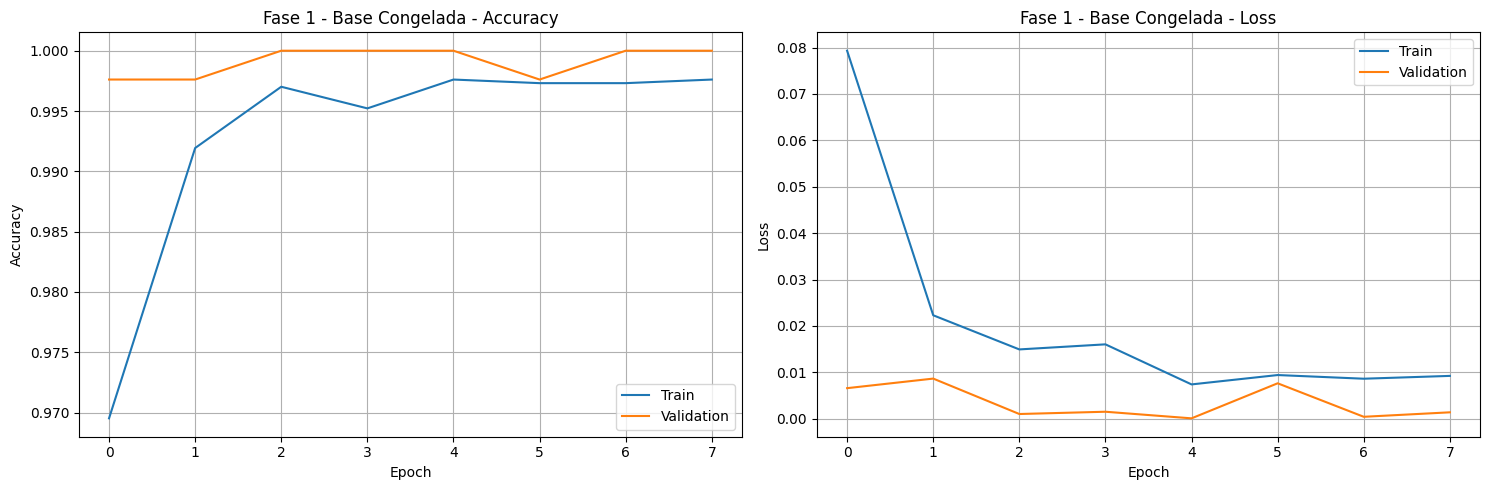

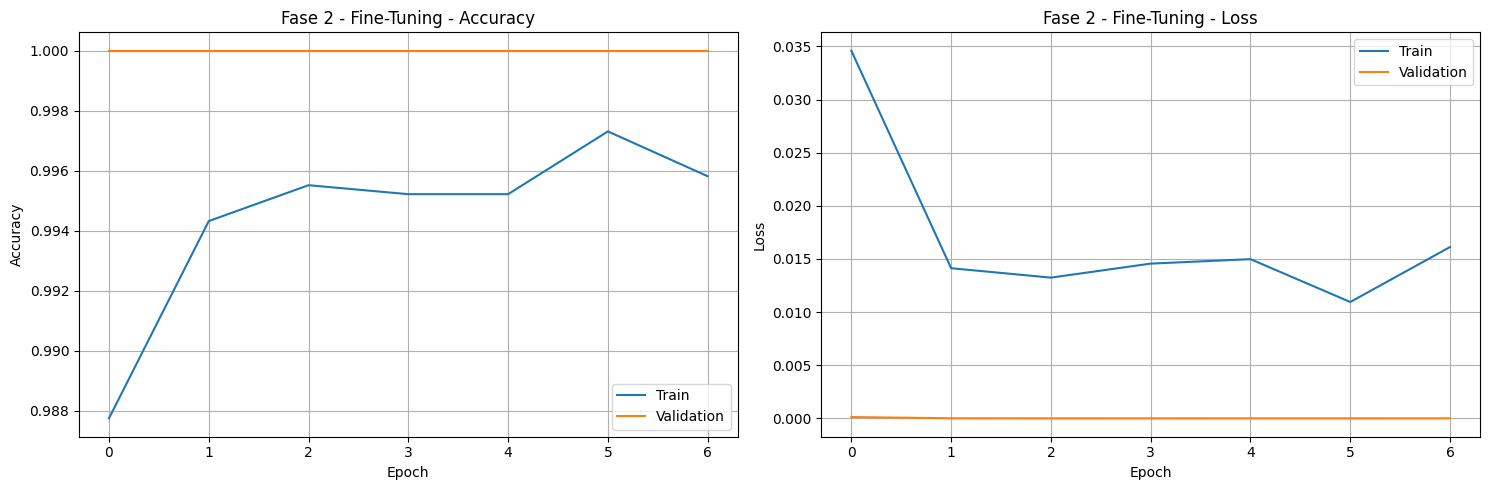

In [49]:
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Accuracy
    ax1.plot(history.history['accuracy'], label='Train')
    ax1.plot(history.history['val_accuracy'], label='Validation')
    ax1.set_title(f'{title} - Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    # Loss
    ax2.plot(history.history['loss'], label='Train')
    ax2.plot(history.history['val_loss'], label='Validation')
    ax2.set_title(f'{title} - Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history_phase1, 'Fase 1 - Base Congelada')
plot_history(history_phase2, 'Fase 2 - Fine-Tuning')

## 💾 Passo 11: Exportar para TensorFlow.js

In [50]:
import tensorflowjs as tfjs
from datetime import datetime
import os

# Versão do modelo
VERSION = datetime.now().strftime('%Y%m%d_%H%M')

# Salvar em formato Keras (.keras obrigatório no Keras 3+)
model.save(f'model_keras_v{VERSION}.keras')
print(f'✅ Modelo Keras salvo')

# Exportar como SavedModel para converter para TF.js
model.export(f'saved_model_v{VERSION}')
print(f'✅ SavedModel exportado')

# Converter para TensorFlow.js
!tensorflowjs_converter \
    --input_format=tf_saved_model \
    --output_format=tfjs_graph_model \
    --signature_name=serving_default \
    --saved_model_tags=serve \
    saved_model_v{VERSION} \
    tfjs_model_v{VERSION}

print(f'✅ Modelo exportado para TensorFlow.js')
print(f'   Versão: {VERSION}')
print(f'   Pasta: tfjs_model_v{VERSION}/')

# Verificar tamanho
total_size = sum(
    os.path.getsize(os.path.join(dirpath, filename))
    for dirpath, dirnames, filenames in os.walk(f'tfjs_model_v{VERSION}')
    for filename in filenames
)
print(f'   Tamanho total: {total_size / 1024 / 1024:.2f} MB')


✅ Modelo Keras salvo
Saved artifact at 'saved_model_v20260317_2334'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_358')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  136435484753360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136435484752016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136435484752208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136435484752784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136435484751440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136435484753552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136435484751824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136435484751632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136435484752592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136435484748944: TensorSpec(shape=(), dtype=tf.re

## 📤 Passo 12: Fazer Download do Modelo

In [51]:
# Compactar modelo
!zip -r tfjs_model_v{VERSION}.zip tfjs_model_v{VERSION}/

# Download
from google.colab import files
files.download(f'tfjs_model_v{VERSION}.zip')

print(f'✅ Modelo compactado e pronto para download')
print(f'\n📋 Próximos passos:')
print(f'   1. Extrair o ZIP')
print(f'   2. Fazer upload dos arquivos para Supabase Storage (bucket: leish-models)')
print(f'   3. Atualizar a tabela model_versions no Supabase')
print(f'   4. Ativar a nova versão no frontend')

  adding: tfjs_model_v20260317_2334/ (stored 0%)
  adding: tfjs_model_v20260317_2334/group1-shard2of3.bin (deflated 7%)
  adding: tfjs_model_v20260317_2334/group1-shard1of3.bin (deflated 7%)
  adding: tfjs_model_v20260317_2334/model.json (deflated 96%)
  adding: tfjs_model_v20260317_2334/group1-shard3of3.bin (deflated 8%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Modelo compactado e pronto para download

📋 Próximos passos:
   1. Extrair o ZIP
   2. Fazer upload dos arquivos para Supabase Storage (bucket: leish-models)
   3. Atualizar a tabela model_versions no Supabase
   4. Ativar a nova versão no frontend


## 📝 Passo 13: Gerar Metadados do Modelo

In [52]:
import json

metadata = {
    'version': VERSION,
    'created_at': datetime.now().isoformat(),
    'architecture': 'MobileNetV2',
    'input_shape': [IMG_SIZE, IMG_SIZE, 3],
    'classes': ['leishmaniose', 'nao_leishmaniose'],
    'metrics': {
        'accuracy': float(results[1]),
        'precision': float(results[2]),
        'recall': float(results[3]),
        'loss': float(results[0])
    },
    'training': {
        'total_images': train_leish + train_nao + val_leish + val_nao,
        'train_images': train_leish + train_nao,
        'val_images': val_leish + val_nao,
        'epochs_phase1': len(history_phase1.history['loss']),
        'epochs_phase2': len(history_phase2.history['loss']),
        'batch_size': BATCH_SIZE
    },
    'preprocessing': {
        'rescale': '1/255',
        'augmentation': [
            'rotation_range=20',
            'width_shift_range=0.2',
            'height_shift_range=0.2',
            'zoom_range=0.2',
            'horizontal_flip=True',
            'brightness_range=[0.8, 1.2]'
        ]
    }
}

# Salvar metadados
with open(f'model_metadata_v{VERSION}.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('✅ Metadados gerados')
print(json.dumps(metadata, indent=2))

# Download metadados
files.download(f'model_metadata_v{VERSION}.json')

✅ Metadados gerados
{
  "version": "20260317_2334",
  "created_at": "2026-03-17T23:35:15.862079",
  "architecture": "MobileNetV2",
  "input_shape": [
    224,
    224,
    3
  ],
  "classes": [
    "leishmaniose",
    "nao_leishmaniose"
  ],
  "metrics": {
    "accuracy": 1.0,
    "precision": 1.0,
    "recall": 1.0,
    "loss": 1.917739837153931e-06
  },
  "training": {
    "total_images": 4183,
    "train_images": 3346,
    "val_images": 837,
    "epochs_phase1": 8,
    "epochs_phase2": 7,
    "batch_size": 16
  },
  "preprocessing": {
    "rescale": "1/255",
    "augmentation": [
      "rotation_range=20",
      "width_shift_range=0.2",
      "height_shift_range=0.2",
      "zoom_range=0.2",
      "horizontal_flip=True",
      "brightness_range=[0.8, 1.2]"
    ]
  }
}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>